In [6]:
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import random
import numpy as np
from PIL import Image, ImageFilter
from PIL import ImageDraw, ImageEnhance
import yaml
import os
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [7]:
# Adds random pixel-wise Gaussian noise to the image tensor
class RandomGaussianNoise:
    def __init__(self, mean=0., std=0.01, p=0.3):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            return tensor + noise
        return tensor

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std}, p={self.p})"

# Applies random Gaussian blur to an image
class RandomGaussianBlur:
    def __init__(self, radius_min=0.1, radius_max=0.5):
        self.radius_min = radius_min
        self.radius_max = radius_max

    def __call__(self, img):
        radius = random.uniform(self.radius_min, self.radius_max)
        return img.filter(ImageFilter.GaussianBlur(radius))

#removed the shadow effect
class RandomShadow:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        shadow = Image.new('L', img.size, 0)
        draw = ImageDraw.Draw(shadow)

        for _ in range(random.randint(1, 3)):
            x1 = random.randint(0, img.width // 2)
            y1 = random.randint(0, img.height)
            x2 = random.randint(img.width // 2, img.width)
            y2 = random.randint(0, img.height)
            x0, x1_sorted = sorted([x1, x2])
            y0, y1_sorted = sorted([y1, y2])
            draw.ellipse([x0, y0, x1_sorted, y1_sorted], fill=random.randint(60, 120))

        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=random.uniform(5, 15)))

        shadow = shadow.convert("RGB")
        shadow = ImageEnhance.Brightness(shadow).enhance(0.6)
        img = Image.blend(img, shadow, alpha=0.5)

        return img

# Adds random black lines to simulate occlusions (like headbands)
class RandomBlackLines:
    def __init__(self, p=0.5, max_lines=5, max_thickness=5):
        self.p = p
        self.max_lines = max_lines
        self.max_thickness = max_thickness

    def __call__(self, img):
        if random.random() > self.p:
            return img

        draw = ImageDraw.Draw(img)
        num_lines = random.randint(1, self.max_lines)

        for _ in range(num_lines):
            x1 = random.randint(0, img.width)
            y1 = random.randint(0, img.height)
            x2 = random.randint(0, img.width)
            y2 = random.randint(0, img.height)
            thickness = random.randint(2, self.max_thickness)
            draw.line((x1, y1, x2, y2), fill=(0, 0, 0), width=thickness)

        return img
    
# Performs a random crop and resize while adjusting bounding boxes
class RandomResizedCropWithBoxes:
    def __init__(self, size, scale=(0.7, 1.0), ratio=(3. / 4., 4. / 3.)):
        self.size = size  # final output size (150)
        self.scale = scale
        self.ratio = ratio

    def get_params(self, img):
        width, height = img.size
        area = height * width

        for _ in range(10):
            target_area = random.uniform(*self.scale) * area
            aspect_ratio = random.uniform(*self.ratio)

            w = int(round((target_area * aspect_ratio) ** 0.5))
            h = int(round((target_area / aspect_ratio) ** 0.5))

            if w <= width and h <= height:
                i = random.randint(0, height - h)
                j = random.randint(0, width - w)
                return i, j, h, w

        # Fallback to center crop
        in_ratio = width / height
        if in_ratio < self.ratio[0]:
            w = width
            h = int(round(w / self.ratio[0]))
        elif in_ratio > self.ratio[1]:
            h = height
            w = int(round(h * self.ratio[1]))
        else:
            w = width
            h = height
        i = (height - h) // 2
        j = (width - w) // 2
        return i, j, h, w

    def __call__(self, img, boxes):
        i, j, h, w = self.get_params(img)

        # Crop and resize image
        img_cropped = TF.resized_crop(img, top=i, left=j, height=h, width=w, size=(self.size, self.size))

        # Adjust boxes
        boxes_out = []
        scale_x = self.size / w
        scale_y = self.size / h

        """for cls, x1, y1, x2, y2 in boxes:
            # Shift by crop origin
            x1_new = (x1 - j) * scale_x
            y1_new = (y1 - i) * scale_y
            x2_new = (x2 - j) * scale_x
            y2_new = (y2 - i) * scale_y

            # Clip to valid bounds
            x1_new = max(0, min(self.size, x1_new))
            y1_new = max(0, min(self.size, y1_new))
            x2_new = max(0, min(self.size, x2_new))
            y2_new = max(0, min(self.size, y2_new))

            # Discard box if completely outside crop
            if x2_new - x1_new > 1 and y2_new - y1_new > 1:
                boxes_out.append((cls, int(x1_new), int(y1_new), int(x2_new), int(y2_new)))"""
        for box in boxes:
            # debug
            cls, x1, y1, x2, y2 = box[:5]
            origin = box[5] if len(box) == 6 else "native"
            # end debug

            x1_new = (x1 - j) * scale_x
            y1_new = (y1 - i) * scale_y
            x2_new = (x2 - j) * scale_x
            y2_new = (y2 - i) * scale_y

            # clip
            x1_new = max(0, min(self.size, x1_new))
            y1_new = max(0, min(self.size, y1_new))
            x2_new = max(0, min(self.size, x2_new))
            y2_new = max(0, min(self.size, y2_new))

            if x2_new - x1_new > 1 and y2_new - y1_new > 1:
                # debug
                boxes_out.append((cls, int(x1_new), int(y1_new), int(x2_new), int(y2_new), origin))
                # end debug
        boxes_out = filter_boxes_by_relative_size(
            boxes_out,
            image_width=self.size,
            image_height=self.size,
            min_size_ratio=0.03  # adjustable
        )

        return img_cropped, boxes_out
    
# Random horizontal flip with box adjustment
class RandomHorizontalFlipWithBoxes:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img, boxes):
        if random.random() > self.p:
            return img, boxes  # no flip

        img = TF.hflip(img)
        w, _ = img.size
        flipped_boxes = []
        """for cls, x1, y1, x2, y2 in boxes:
            new_x1 = w - x2
            new_x2 = w - x1
            flipped_boxes.append((cls, new_x1, y1, new_x2, y2))"""
        for box in boxes:
            # debug
            cls, x1, y1, x2, y2 = box[:5]
            origin = box[5] if len(box) == 6 else "native"
            # end debug

            new_x1 = w - x2
            new_x2 = w - x1
            # debug
            flipped_boxes.append((cls, new_x1, y1, new_x2, y2, origin))
            # end debug

        return img, flipped_boxes
    
# Random vertical flip with box adjustment
class RandomVerticalFlipWithBoxes:
    def __init__(self, p=0.2):
        self.p = p

    def __call__(self, img, boxes):
        if random.random() > self.p:
            return img, boxes  # no flip

        img = TF.vflip(img)
        _, h = img.size
        flipped_boxes = []
        """for cls, x1, y1, x2, y2 in boxes:
            new_y1 = h - y2
            new_y2 = h - y1
            flipped_boxes.append((cls, x1, new_y1, x2, new_y2))"""
        for box in boxes:
            # debug
            cls, x1, y1, x2, y2 = box[:5]
            origin = box[5] if len(box) == 6 else "native"
            # end debug

            new_y1 = h - y2
            new_y2 = h - y1
            # debug
            flipped_boxes.append((cls, x1, new_y1, x2, new_y2, origin))
            # end debug

        return img, flipped_boxes

# Removes bounding boxes that are too small compared to image size
def filter_boxes_by_relative_size(boxes, image_width, image_height, min_size_ratio=0.03):
    min_w = image_width * min_size_ratio
    min_h = image_height * min_size_ratio

    """filtered = []
    for cls, x1, y1, x2, y2 in boxes:
        w = x2 - x1
        h = y2 - y1
        if w >= min_w and h >= min_h:
            filtered.append((cls, x1, y1, x2, y2))
    return filtered"""
    # for debug
    filtered = []
    for box in boxes:
        cls, x1, y1, x2, y2 = box[:5]
        origin = box[5] if len(box) == 6 else "native"
        w = x2 - x1
        h = y2 - y1
        if w >= min_w and h >= min_h:
            filtered.append((cls, x1, y1, x2, y2, origin))
    return filtered
    #end debug

# Computes IoU (Intersection over Union) between two boxes (to remove pasted images that cover too much of another box)
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    if inter_area == 0:
        return 0.0

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter_area

    return inter_area / union

# Light random augmentations
random_augmentations = [
    T.ColorJitter(brightness=0.1, contrast=0.2, saturation=0.2, hue=0.05),#(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    RandomGaussianBlur(),
    #RandomShadow(p=0.7),
    RandomBlackLines(p=0.5, max_lines=5, max_thickness=4),
]

# Randomly apply a subset of the defined augmentations
class RandomSubsetTransform:
    def __init__(self, transforms, num_choices=2):
        self.transforms = transforms
        self.num_choices = num_choices

    def __call__(self, img):
        chosen_transforms = random.sample(self.transforms, self.num_choices)
        for t in chosen_transforms:
            img = t(img)
        return img


# Final composed transform for training (doesn't include the ones that require modification of the boxes)
train_transform_balanced = T.Compose([
    RandomSubsetTransform(random_augmentations, num_choices=2),
    T.ToTensor(),
    RandomGaussianNoise(0., 0.02, p=0.3),
    T.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


In [8]:
class ChocolateCutPasteDataset(Dataset):
    """
    A PyTorch dataset for chocolate images with YOLO-style annotations,
    supporting CutPaste augmentation and geometrical transforms (crop, flip),
    while keeping bounding boxes updated accordingly.
    """
    def __init__(self, image_dir, label_dir, transform=None, cutpaste_p=0.5,
                 crop_resize_with_boxes=None, flip_with_boxes=None, vflip_with_boxes=None, min_size_ratio=0.05, max_iou=0.3):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".jpg")])
        self.transform = transform
        self.crop_resize_with_boxes = crop_resize_with_boxes
        self.cutpaste_p = cutpaste_p
        self.flip_with_boxes = flip_with_boxes
        self.vflip_with_boxes = vflip_with_boxes
        self.min_size_ratio = min_size_ratio # minimum relative box size
        self.max_iou = max_iou # max allowed IoU between donor and existing boxes
        
        
    def __len__(self):
        return len(self.image_files)

    def load_labels(self, label_path, img_width, img_height):
        """
        Loads bounding boxes from YOLO-format .txt file.
        Converts normalized xywh → pixel x1y1x2y2
        """
        boxes = []
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, w, h = map(float, line.strip().split())
                x1 = int((x - w / 2) * img_width)
                y1 = int((y - h / 2) * img_height)
                x2 = int((x + w / 2) * img_width)
                y2 = int((y + h / 2) * img_height)
                boxes.append((int(cls), x1, y1, x2, y2))
        return boxes

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        image = Image.open(img_path).convert("RGB")
        width, height = image.size
        boxes = self.load_labels(label_path, width, height)
        #for debug
        boxes = [(cls, x1, y1, x2, y2, "native") for (cls, x1, y1, x2, y2) in boxes]
        # end debug

        # -----------------------------
        # CutPaste logic
        # -----------------------------
        if random.random() < self.cutpaste_p and len(boxes) > 0:
            donor_idx = random.randint(0, len(self.image_files) - 1)
            donor_name = self.image_files[donor_idx]
            donor_img_path = os.path.join(self.image_dir, donor_name)
            donor_label_path = os.path.join(self.label_dir, donor_name.replace(".jpg", ".txt"))

            donor_img = Image.open(donor_img_path).convert("RGB")
            donor_width, donor_height = donor_img.size
            donor_boxes = self.load_labels(donor_label_path, donor_width, donor_height)

            if len(donor_boxes) > 0:
                cls, x1, y1, x2, y2 = random.choice(donor_boxes)
                donor_crop = donor_img.crop((x1, y1, x2, y2))

                crop_w, crop_h = x2 - x1, y2 - y1
                if crop_w < width and crop_h < height:
                    paste_x = random.randint(0, width - crop_w)
                    paste_y = random.randint(0, height - crop_h)

                    # debug: Check IoU overlap with existing boxes
                    donor_box_coords = (paste_x, paste_y, paste_x + crop_w, paste_y + crop_h)
                    overlap_too_high = False
                    for b in boxes:
                        _, bx1, by1, bx2, by2 = b[:5]
                        iou = compute_iou((bx1, by1, bx2, by2), donor_box_coords)
                        if iou > self.max_iou:
                            overlap_too_high = True
                            break
                    # end debug

                    if overlap_too_high:
                        print("[CutPaste] Skipped donor box due to high IoU overlap")
                    else:
                        image.paste(donor_crop, (paste_x, paste_y))
                        # debug: append box with donor tag
                        cutpaste_box = (cls, *donor_box_coords, "donor")
                        boxes.append(cutpaste_box)
                        cutpaste_box_added = True
                        # end debug

        # -----------------------------
        # Geometric transforms (with box tracking)
        # -----------------------------
        if self.crop_resize_with_boxes:
            image, boxes = self.crop_resize_with_boxes(image, boxes)

        if self.flip_with_boxes:
            image, boxes = self.flip_with_boxes(image, boxes)

        if self.vflip_with_boxes:
            image, boxes = self.vflip_with_boxes(image, boxes)
    
        # -----------------------------
        # Discard too-small boxes
        # -----------------------------
        if self.min_size_ratio:
            #width, height = image.size
            #boxes = filter_boxes_by_relative_size(boxes, width, height, self.min_size_ratio)
            ##for debug
            width, height = image.size
            original_box_count = len(boxes)
            boxes = filter_boxes_by_relative_size(boxes, width, height, self.min_size_ratio)
            if 'cutpaste_box_added' in locals() and cutpaste_box not in boxes:
                print(f"[CutPaste] Donor box discarded due to small size (under {self.min_size_ratio*100:.1f}%)")
            ##end debug

        # -----------------------------
        # Final additional transforms (jitter, blur, etc.)
        # -----------------------------
        if self.transform:
            image = self.transform(image)
        return image, boxes
    

    ##note:
    #to use tranformations that affect the boxes, you need to pass them as arguments to the dataset
    #ex:

    #cropper = RandomResizedCropWithBoxes(size=150)
    #flipper = RandomHorizontalFlipWithBoxes(p=0.5)
    #vflipper = RandomVerticalFlipWithBoxes(p=1.0) 

    #dataset = ChocolateCutPasteDataset(
    #    image_dir="...",
    #    label_dir="...",
    #    transform=train_transform_balanced,
    #    crop_resize_with_boxes=cropper,
    #    flip_with_boxes=flipper,
    #    vflip_with_boxes=vflipper,
    #    cutpaste_p=0.5
    #)

In [ ]:

cropper = RandomResizedCropWithBoxes(size=150)
flipper = RandomHorizontalFlipWithBoxes(p=0.5)
vflipper = RandomVerticalFlipWithBoxes(p=1.0) 

dataset = ChocolateCutPasteDataset(
    image_dir="/Users/lunnet_1/Downloads/FullDataset/train/images",
    label_dir="/Users/lunnet_1/Downloads/FullDataset/train/labels",
    transform=train_transform_balanced,
    crop_resize_with_boxes=cropper,
    flip_with_boxes=flipper,
    vflip_with_boxes=vflipper,
    cutpaste_p=0.5
    
)



code to visualize:

[CutPaste] Donor box discarded due to small size (under 5.0%)
[CutPaste] Donor box discarded due to small size (under 5.0%)
[CutPaste] Donor box discarded due to small size (under 5.0%)
[CutPaste] Donor box discarded due to small size (under 5.0%)


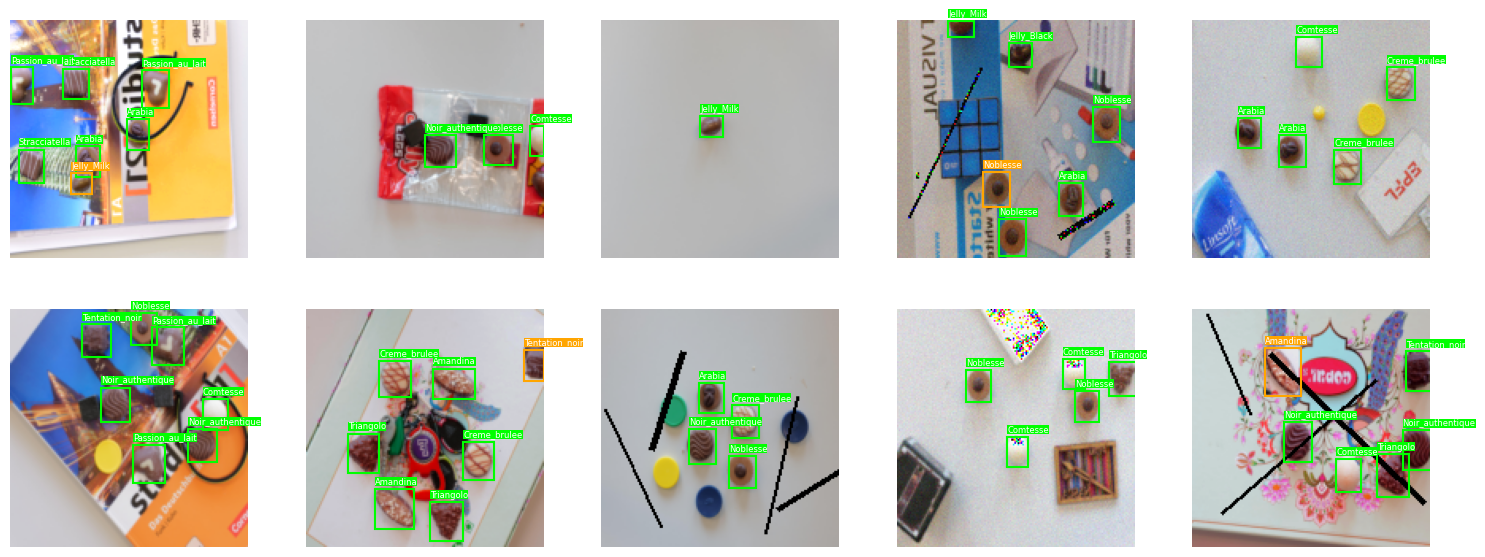

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torchvision.transforms.functional as TF

def unnormalize(t):
    return t * 0.5 + 0.5
def show_transformed_batch(dataset, rows=2, cols=5, class_names=None):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        idx = torch.randint(len(dataset), (1,)).item()
        img_tensor, boxes = dataset[idx]

        img = TF.to_pil_image(unnormalize(img_tensor))
        ax.imshow(img)
        ax.axis('off')

        for box in boxes:
            if len(box) == 6:
                cls, x1, y1, x2, y2, origin = box
            else:
                cls, x1, y1, x2, y2 = box
                origin = "native"

            color = "orange" if origin == "donor" else "lime"
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5,
                                     edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            if class_names:
                ax.text(x1, y1 - 3, class_names[cls], fontsize=6, color='white',
                        bbox=dict(facecolor=color, pad=0, edgecolor='none'))

    plt.tight_layout()
    plt.show()

show_transformed_batch(
    dataset,
    rows=2,
    cols=5,
    class_names=[
        'Amandina', 'Arabia', 'Comtesse', 'Creme_brulee', 'Jelly_Black', 'Jelly_Milk',
        'Jelly_White', 'Noblesse', 'Noir_authentique', 'Passion_au_lait', 'Stracciatella',
        'Tentation_noir', 'Triangolo'
    ]
)


Estimating number of variants (using chatgpt)

Horizontal Flip (p=0.5) | 2 (flip or not)
Vertical Flip (p=0.2) | 2 (flip or not)
RandomSubsetTransform | C(3, 2) = 3
Gaussian Noise (p=0.3) | 2 (with or without)
CutPaste (p=0.5) | 2 (applied or not)
RandomResizedCrop | continuous (infinite)

Estimated distinct discrete variants=2×2×3×2×2= 48

Per image, pipeline can generate at least 48 distinct logical augmentation paths — and realistically hundreds or thousands due to randomness in: crop parameters, jitter values, Gaussian noise, CutPaste donor/image choice
​
